In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


def non_dim_scat_len(intensity, detuning, loss=0):
    # l* = a_bg 
    loss = float(loss)
    I = jnp.asarray(intensity, dtype=jnp.complex64) 
    v = jnp.asarray(detuning, dtype=jnp.complex64) 

    scattering_length = 1.0 + (I / (-v - I + loss * 0.5j))

    return scattering_length






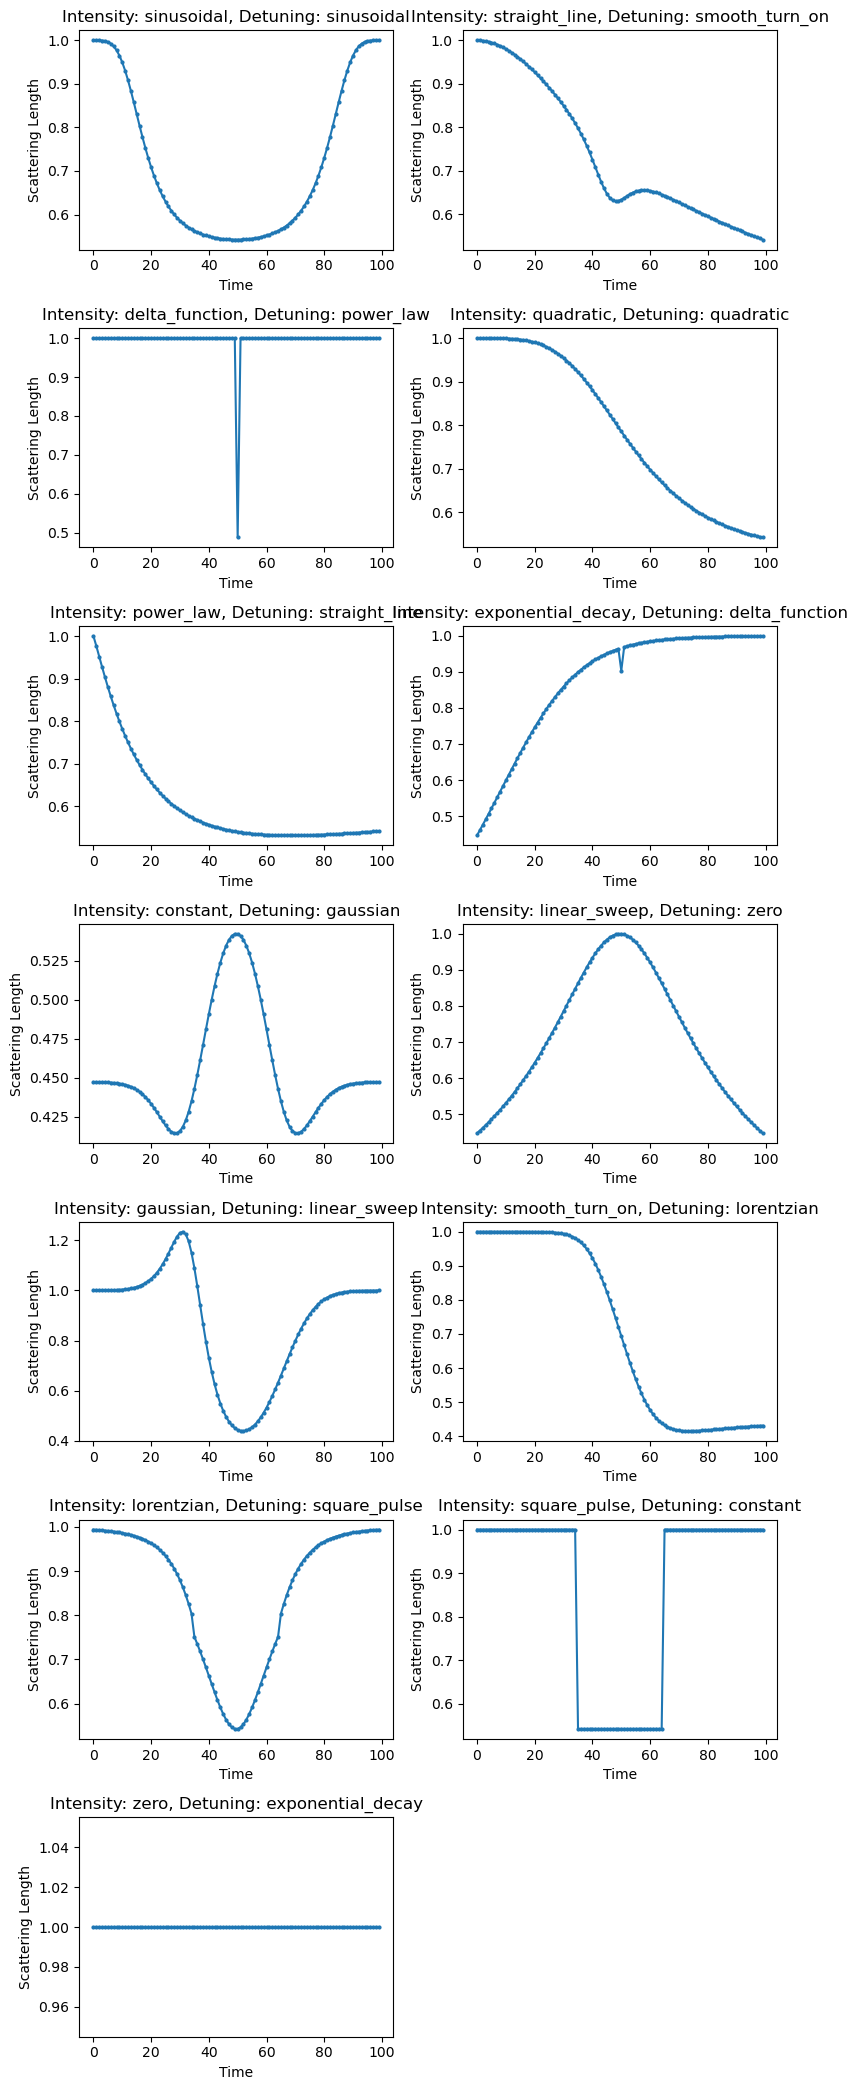

In [15]:
%run ./test.ipynb
import math
import numpy as np
import matplotlib.pyplot as plt

test_variable_names = ["Intensity", "Detuning"]
array_length = 100
random_seed = 0
curve_types_to_test = None 
complex_values = False
x_axis_name = "Time"
y_axis_name = "Scattering Length"
plot_columns = 2
fixed_args_before_test_arrays = () 
fixed_args_after_test_arrays = ([1]) 

function_under_test = non_dim_scat_len

dataset = make_test_dataset(
    test_variable_names,
    length=array_length,
    seed=random_seed,
    curve_types=curve_types_to_test,
    complex_values=complex_values,
)
test_combinations = list(zip(*(dataset[name] for name in dataset.names)))

results = []
for curves in test_combinations:
    test_arrays = [curve.values for curve in curves]
    output_array = function_under_test(
        *fixed_args_before_test_arrays,
        *test_arrays,
        *fixed_args_after_test_arrays,
    )
    results.append((curves, output_array))

if not results:
    raise ValueError("No test combinations were generated.")

ncols = min(max(1, plot_columns), len(results))
nrows = math.ceil(len(results) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
axes = axes.ravel()

for ax, (curves, y_values) in zip(axes, results):
    y_values = np.asarray(y_values)
    time = range(len(y_values))
    title = ", ".join(f"{curve.name}: {curve.curve_type}" for curve in curves)
    if np.iscomplexobj(y_values):
        y_values = np.abs(y_values)
    ax.plot(time, y_values, marker="o", markersize=2, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)

for ax in axes[len(results):]:
    ax.set_visible(False)

fig.tight_layout()